Creating configuration: 2D_initial_configurations/2D_neurons_params_PBC_random_L2.0_rho150_l1.20_d0.15.txt
Gini coefficient: 0.42300625


c:\Users\Admin\Desktop\Master\TFM\functions_create_networks.py:262: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=15, loc='lower right', frameon=False)


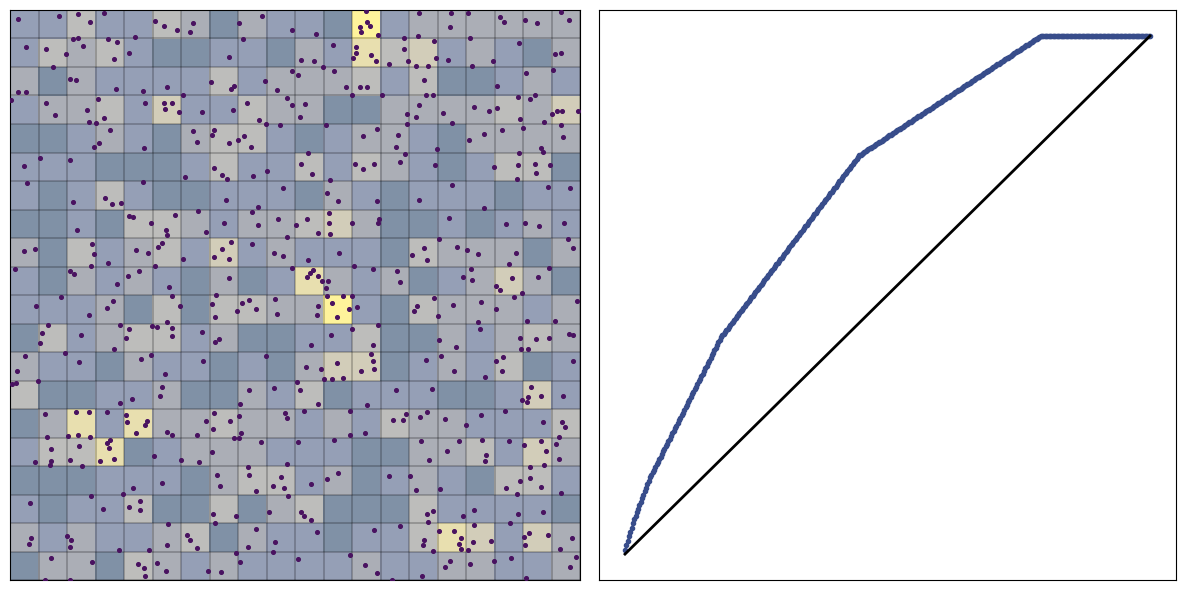

In [66]:
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from pypalettes import load_cmap 
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)

compile_result = subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-Wall", 
    "-O3",
    "2D_tune_positions.c",
    "2D_functions.c",
    "-o",
    "2D_tune_positions.exe",
    "-lm"
])

L = 2 # Length of the square domain (mm)
rho = 150 # Neuron density (neurons/mm^2)
N = int(rho * L**2) # Total number of neurons
soma_diameter = 0.015 # Diameter of the soma (mm)
d_mean = 0.15 # Dendritic tree diameter (mm) Gaussian distribution
d_sigma = 0.02 # Standard deviation of the dendritic tree diameter (mm) 
l_mean = 1.2 # Mean axon length (mm) Rayleigh distribution
segment_length = 0.01 # Segment length for axon growth (mm)
sigma_axon_angle = 0.1 # Standard deviation of the axon angle (radians)

agg = 0 # Control parameter for the aggregation of neurons
n_centers = 10 # Number of centers for the aggregation of neurons
base_sigma = 0.4 # Base standard deviation for aggregation centers (mm)

BC_type = "PBC" # Boundary conditions type (PBC: Periodic Boundary Conditions, SW: Sticky Walls)

parameters2D = {
    "L": L,
    "rho": rho,
    "soma_diameter": soma_diameter,
    "d_mean": d_mean,
    "d_sigma": d_sigma,
    "l_mean": l_mean,
    "segment_length": segment_length,
    "sigma_axon_angle": sigma_axon_angle,
    "agg": agg,
    "n_centers": n_centers,
    "base_sigma": base_sigma,
    "BC_type": BC_type
}

filename = fcn.run_2D_tune_positions(parameters2D, new_sim=True)
fcn.neuron_map_gini2D(filename, parameters2D)

Creating configuration: 2D_created_networks/2D_adjacency_matrix_PBC_agg_nc10_s0.0400_L2.0_rho150_l1.20_d0.15.txt
Number of connections in original network: 33951
Number of connections after applying alpha = 0.2: 27629
Fraction of connections after applying alpha = 0.2: 0.8138


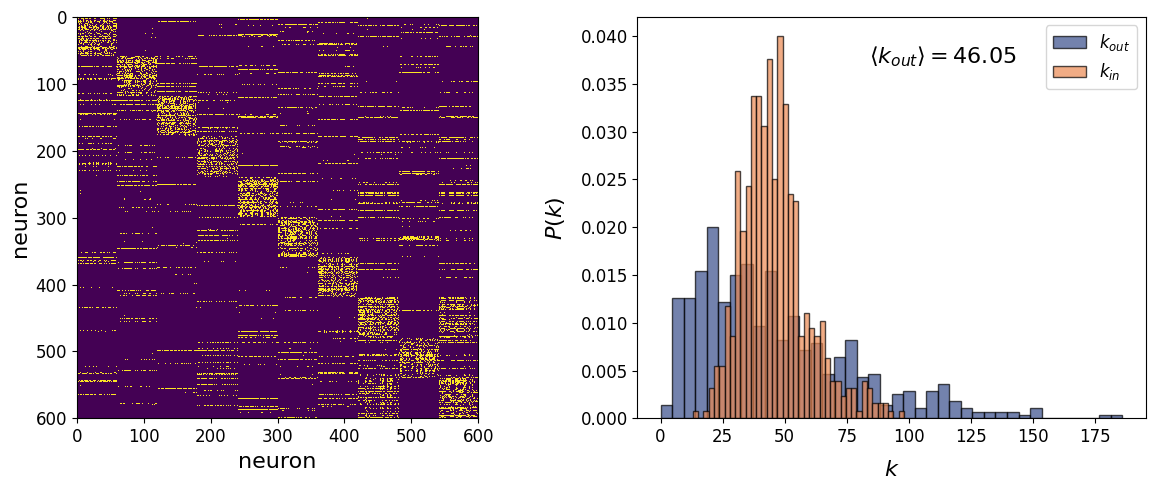

In [63]:
import subprocess
import numpy as np
import importlib
import functions_create_networks as fcn
importlib.reload(fcn)
import matplotlib.pyplot as plt
sunset2 = load_cmap('Sunset2', cmap_type='continuous')

# compilar
subprocess.run([
    "C:/msys64/ucrt64/bin/gcc.exe",
    "-O3",
    "2D_create_network.c",
    "2D_functions.c",
    "-o",
    "2D_create_network.exe",
    "-lm"
])

alpha = 0.2
# alphas = np.arange(0.0, 1.01, 0.01)

output_filename = fcn.create_network2D(parameters2D, show_prints_c=False, show_prints_control=True) # Here the conections network is created and saved in a file

M = fcn.load_A(output_filename) # M is th amtrix with the number of tries for each connection between neurons
number_of_connections = np.count_nonzero(M) 
print(f"Number of connections in original network: {number_of_connections}")

A, output_filename = fcn.modify_A_alpha2D(M, alpha, parameters2D)
number_of_successful_connections = A.sum()
print(f"Number of connections after applying alpha = {alpha}: {number_of_successful_connections}")

print(f"Fraction of connections after applying alpha = {alpha}: {number_of_successful_connections/number_of_connections:.4f}")

# =========================
# PLOTS DE ESTRUCTURA DE LA RED
# =========================


# =========================
# GRADO
# =========================
# Red dirigida: out-degree = suma por filas
k_out = A.sum(axis=1)
k_in = A.sum(axis=0)

# Para histograma discreto
k_vals = np.arange(k_out.max() + 1)
counts = np.bincount(k_out)

# =========================
# FIGURA CON DOS SUBPLOTS
# =========================
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --------- MATRIZ DE ADYACENCIA ---------
ax = axs[0]
ax.imshow(A, aspect='equal', interpolation='nearest')

ax.set_xlim(0, A.shape[0])
ax.set_ylim(A.shape[0], 0)
ax.set_xlabel('neuron', fontsize=16)
ax.set_ylabel('neuron', fontsize=16)
ax.tick_params(labelsize=12)

# --------- DISTRIBUCIÓN DE GRADO ---------
k_out_mean = k_out.mean()
# k_in_mean = k_in.mean()
ax = axs[1]

ax.hist(k_out, bins=40, density=True, color=sunset2(0.1), edgecolor='black', alpha=0.7, label = r'$k_{out}$')
ax.hist(k_in, bins=40, density=True, color=sunset2(0.8), edgecolor='black', alpha = 0.7, label = r'$k_{in}$')

# ax.text(0.75, 0.85, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$\n$\\langle k_{{in}} \\rangle = {k_in_mean:.2f}$", fontsize=14, ha='center', va='center', transform=ax.transAxes)

ax.text(0.6, 0.9, f"$\\langle k_{{out}} \\rangle = {k_out_mean:.2f}$", fontsize=16, ha='center', va='center', transform=ax.transAxes)

ax.set_xlabel(r'$k$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$P(k)$', fontsize=16, labelpad=10)
ax.legend(fontsize = 12, loc = 'upper right')
ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

# Hacer una matrix de las posibles conexiones que puede hace un axon y luego eliminar de acuerdo a la alpha

In [64]:
import pandas as pd

input_file = "2D_initial_configurations/2D_neurons_params_PBC_agg_nc10_s0.0400_L2.0_rho150_l1.20_d0.15.txt"
# input_file = "2D_initial_configurations/2D_neurons_params_PBC_random_L2.0_rho150_l1.20_d0.15.txt"
output_file = "nodes.csv"

# Leer líneas
with open(input_file, "r", encoding="utf-8") as f:
    lines = f.readlines()

# Buscar la línea donde empieza la tabla
start_idx = None
for i, line in enumerate(lines):
    if line.strip().startswith("X") and "Y" in line:
        start_idx = i
        break

if start_idx is None:
    raise ValueError("No se encontró la cabecera de la tabla de nodos.")

# Leer tabla desde ahí
from io import StringIO
table_text = "".join(lines[start_idx:])
df = pd.read_csv(StringIO(table_text), sep=r"\s+")

# Añadir columnas para Gephi
df.insert(0, "id", range(len(df)))
df.insert(1, "label", range(len(df)))

# Renombrar columnas
df = df.rename(columns={
    "X": "x",
    "Y": "y",
    "Soma_Diameter": "soma_diameter",
    "Dendrite_Diameter": "dendrite_diameter",
    "Axon_Length": "axon_length"
})

# Guardar
df.to_csv(output_file, index=False)

print(f"Guardado {output_file} con {len(df)} nodos.")

Guardado nodes.csv con 600 nodos.


In [65]:
import numpy as np
import pandas as pd

# adj_file = "2D_dynamics/networks_for_dynamics/2D_adjacency_matrix_PBC_agg_nc25_s0.2000_L3.0_rho250_l0.30_d0.15_a0.20.txt"
edges_file = "edges.csv"

# A = np.loadtxt(adj_file)

sources = []
targets = []
weights = []
types = []

N = A.shape[0]

for i in range(N):
    for j in range(N):
        if A[i, j] != 0:
            sources.append(i)
            targets.append(j)
            weights.append(A[i, j])
            types.append("Directed")   # o "Undirected"

edges_df = pd.DataFrame({
    "source": sources,
    "target": targets,
    "weight": weights,
    "type": types
})

edges_df.to_csv(edges_file, index=False)

print(f"Guardado {edges_file} con {len(edges_df)} enlaces.")

Guardado edges.csv con 27629 enlaces.


Figura guardada en: spatial_graph_curved_dendrites.png


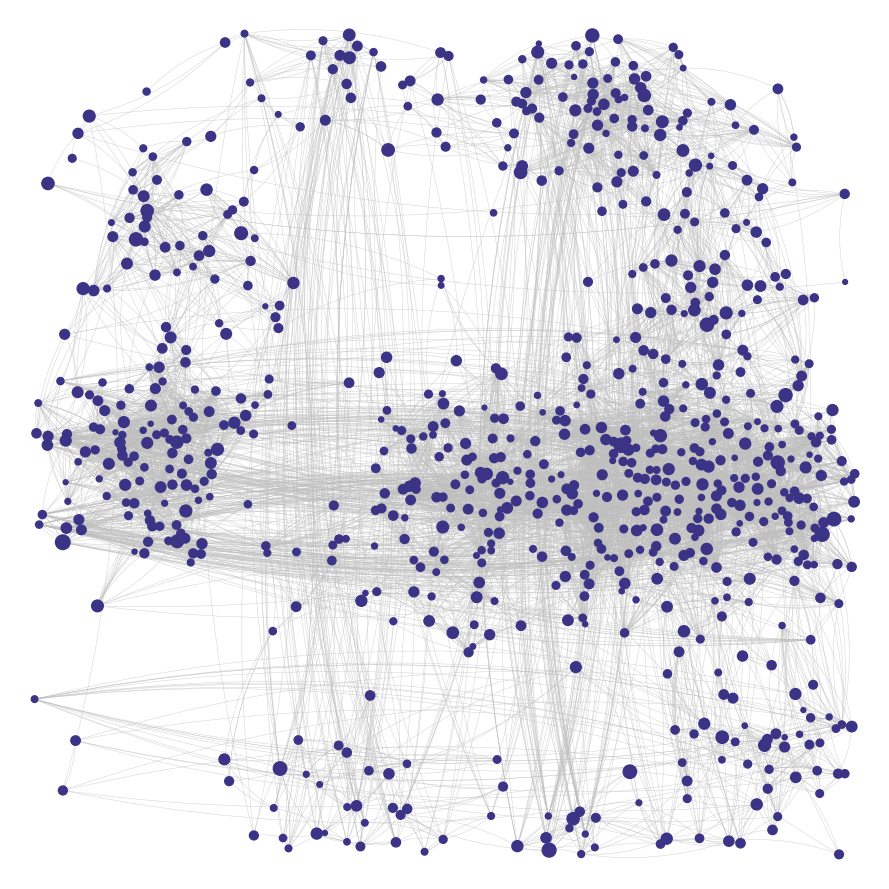

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch


def plot_spatial_graph_curved_dendrites(
    nodes_file,
    edges_file,
    output_file=None,
    figsize=(9, 9),
    node_color="#352a87",
    edge_color="0.75",
    edge_linewidth=0.20,
    edge_alpha=0.15,
    curvature=0.12,
    show_axes=False,
    dpi=400,
    title=None,
    seed=42,
    min_node_size=15,
    max_node_size=140,
    use_raw_diameter=False,
    raw_size_scale=4000
):
    """
    Dibuja un grafo espacial con:
      - posiciones reales x,y
      - aristas curvas
      - tamaño de nodo basado en dendrite_diameter

    Parámetros
    ----------
    nodes_file : str
        CSV de nodos con columnas: id, x, y, dendrite_diameter
    edges_file : str
        CSV de aristas con columnas: source, target
    output_file : str or None
        Archivo de salida para guardar la figura
    figsize : tuple
        Tamaño de la figura
    node_color : str
        Color de los nodos
    edge_color : str
        Color de las aristas
    edge_linewidth : float
        Grosor de las aristas
    edge_alpha : float
        Transparencia de las aristas
    curvature : float
        Curvatura relativa de las aristas
    show_axes : bool
        Mostrar o no los ejes
    dpi : int
        Resolución de guardado
    title : str or None
        Título
    seed : int
        Semilla para el lado de curvatura
    min_node_size : float
        Tamaño mínimo de nodo si se normaliza
    max_node_size : float
        Tamaño máximo de nodo si se normaliza
    use_raw_diameter : bool
        Si True, usa tamaño proporcional al diámetro real al cuadrado
        Si False, normaliza los diámetros para visualización
    raw_size_scale : float
        Factor de escala si use_raw_diameter=True
    """

    rng = np.random.default_rng(seed)

    # -------------------------
    # Leer archivos
    # -------------------------
    nodes = pd.read_csv(nodes_file)
    edges = pd.read_csv(edges_file)

    # -------------------------
    # Comprobaciones
    # -------------------------
    required_node_cols = {"id", "x", "y", "dendrite_diameter"}
    required_edge_cols = {"source", "target"}

    if not required_node_cols.issubset(nodes.columns):
        raise ValueError(
            f"El archivo de nodos debe contener las columnas {required_node_cols}. "
            f"Columnas encontradas: {list(nodes.columns)}"
        )

    if not required_edge_cols.issubset(edges.columns):
        raise ValueError(
            f"El archivo de aristas debe contener las columnas {required_edge_cols}. "
            f"Columnas encontradas: {list(edges.columns)}"
        )

    nodes = nodes.copy()
    edges = edges.copy()

    # Normalizar ids a string para evitar problemas de comparación
    nodes["id"] = nodes["id"].astype(str)
    edges["source"] = edges["source"].astype(str)
    edges["target"] = edges["target"].astype(str)

    # -------------------------
    # Posiciones
    # -------------------------
    pos = dict(zip(nodes["id"], zip(nodes["x"], nodes["y"])))

    # -------------------------
    # Tamaño de nodos a partir del diámetro dendrítico
    # Recordatorio: s en scatter representa área
    # -------------------------
    d = nodes["dendrite_diameter"].to_numpy(dtype=float)

    if np.any(d < 0):
        raise ValueError("Hay valores negativos en dendrite_diameter.")

    if use_raw_diameter:
        # Tamaño proporcional al área ~ diámetro^2
        sizes = raw_size_scale * (d ** 2)
    else:
        # Normalización visual más estable
        if np.allclose(d.max(), d.min()):
            sizes = np.full_like(d, 0.5 * (min_node_size + max_node_size), dtype=float)
        else:
            d_norm = (d - d.min()) / (d.max() - d.min())
            sizes = min_node_size + (max_node_size - min_node_size) * (d_norm ** 2)

    # -------------------------
    # Figura
    # -------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # -------------------------
    # Dibujar aristas curvas
    # -------------------------
    missing_nodes = set()

    for _, row in edges.iterrows():
        s = row["source"]
        t = row["target"]

        if s not in pos:
            missing_nodes.add(s)
            continue
        if t not in pos:
            missing_nodes.add(t)
            continue

        x1, y1 = pos[s]
        x2, y2 = pos[t]

        dx = x2 - x1
        dy = y2 - y1
        dist = np.hypot(dx, dy)

        if dist == 0:
            continue

        # Vector perpendicular unitario
        px = -dy / dist
        py = dx / dist

        # Elegimos lado de curvatura
        sign = rng.choice([-1, 1])

        # Punto medio
        mx = 0.5 * (x1 + x2)
        my = 0.5 * (y1 + y2)

        # Punto de control
        cx = mx + sign * curvature * dist * px
        cy = my + sign * curvature * dist * py

        verts = [
            (x1, y1),
            (cx, cy),
            (x2, y2)
        ]

        codes = [
            Path.MOVETO,
            Path.CURVE3,
            Path.CURVE3
        ]

        path = Path(verts, codes)
        patch = PathPatch(
            path,
            facecolor="none",
            edgecolor=edge_color,
            lw=edge_linewidth,
            alpha=edge_alpha,
            zorder=1
        )
        ax.add_patch(patch)

    if missing_nodes:
        print(
            f"Aviso: hay {len(missing_nodes)} nodos referenciados en edges "
            f"que no existen en nodes. Se ignorarán."
        )

    # -------------------------
    # Dibujar nodos
    # -------------------------
    ax.scatter(
        nodes["x"],
        nodes["y"],
        s=sizes,
        c=node_color,
        zorder=2
    )

    # -------------------------
    # Límites
    # -------------------------
    xmin, xmax = nodes["x"].min(), nodes["x"].max()
    ymin, ymax = nodes["y"].min(), nodes["y"].max()

    dx = xmax - xmin
    dy = ymax - ymin
    mx = 0.03 * dx if dx > 0 else 0.1
    my = 0.03 * dy if dy > 0 else 0.1

    ax.set_xlim(xmin - mx, xmax + mx)
    ax.set_ylim(ymin - my, ymax + my)
    ax.set_aspect("equal")

    # -------------------------
    # Título y ejes
    # -------------------------
    if title is not None:
        ax.set_title(title)

    if show_axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()

    # -------------------------
    # Guardar
    # -------------------------
    if output_file is not None:
        plt.savefig(output_file, dpi=dpi, bbox_inches="tight")
        print(f"Figura guardada en: {output_file}")

    plt.show()


if __name__ == "__main__":
    plot_spatial_graph_curved_dendrites(
        nodes_file="nodes.csv",
        edges_file="edges.csv",
        output_file="spatial_graph_curved_dendrites.png",
        figsize=(9, 9),
        node_color="#3b3486",
        edge_color="0.75",
        edge_linewidth=0.3,
        edge_alpha=0.8,
        curvature=0.12,
        show_axes=False,
        dpi=400,
        title=None,
        seed=42,
        min_node_size=12,
        max_node_size=110,
        use_raw_diameter=False,
        raw_size_scale=4000
    )